In [1]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [3]:
!pip -q install torch torchvision torchaudio matplotlib pillow

import os, glob, shutil, zipfile

zip_candidates = [p for p in os.listdir('/content') if p.lower().endswith('.zip')]
if zip_candidates:
    zip_path = max([os.path.join('/content', z) for z in zip_candidates], key=os.path.getmtime)
    print("Found ZIP:", zip_path)
    for d in ["sample_computer_vision"]:
        shutil.rmtree(f"/content/{d}", ignore_errors=True)
    !unzip -q -o "$zip_path" -d /content
else:
    print("No ZIP found in /content. If using Google Drive, mount it and set data_dir manually in Cell 2.")
candidates = []
for d in glob.glob("/content/**", recursive=True):
    if (os.path.isdir(os.path.join(d, "train")) and
        os.path.isdir(os.path.join(d, "val"))):
        candidates.append(d)

print("Found data_dir candidates:", candidates[:5])


Found ZIP: /content/sample_computer_vision.zip
Found data_dir candidates: ['/content/sample_computer_vision']


In [4]:
import os, glob

data_dir = None
for d in glob.glob("/content/**", recursive=True):
    if os.path.isdir(os.path.join(d, "train")) and os.path.isdir(os.path.join(d, "val")):
        data_dir = d
        break

print("data_dir:", data_dir)
assert data_dir and os.path.isdir(os.path.join(data_dir, "train")), "train/ 폴더를 찾지 못했습니다."
assert os.path.isdir(os.path.join(data_dir, "val")), "val/ 폴더를 찾지 못했습니다."


data_dir: /content/sample_computer_vision


Device: cuda
classes: ['cats', 'dogs']


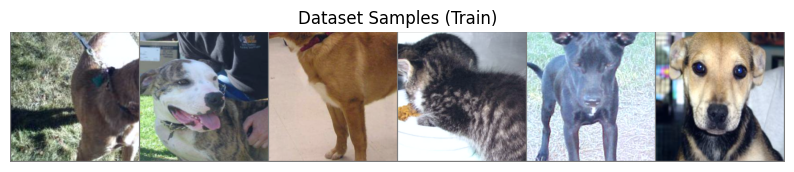

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


Epoch 1/3 | train | loss: 0.6397 | acc: 0.7146
Epoch 1/3 | val   | loss: 1.9821 | acc: 0.6350
Epoch 2/3 | train | loss: 0.5371 | acc: 0.7275
Epoch 2/3 | val   | loss: 1.0039 | acc: 0.6650
Epoch 3/3 | train | loss: 0.4329 | acc: 0.8044
Epoch 3/3 | val   | loss: 0.2979 | acc: 0.8650
Best val acc: 0.865


In [7]:
import torch, torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import torch.nn as nn, torch.optim as optim
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt
import numpy as np, time, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tfm = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
}

datasets_ = {x: datasets.ImageFolder(os.path.join(data_dir,x), tfm[x]) for x in ["train","val"]}
dataloaders = {x: DataLoader(datasets_[x], batch_size=16, shuffle=(x=="train")) for x in ["train","val"]}
class_names = datasets_["train"].classes
print("classes:", class_names)

# ① 데이터셋 시각화 (6장)
imgs, lbls = next(iter(dataloaders["train"]))
grid = torchvision.utils.make_grid(imgs[:6])
grid = grid.numpy().transpose((1,2,0))
grid = np.clip(grid*0.229+0.485, 0, 1)
plt.figure(figsize=(10,3))
plt.imshow(grid); plt.axis("off"); plt.title("Dataset Samples (Train)")
os.makedirs("/content/outputs", exist_ok=True)
plt.savefig("/content/outputs/dataset_samples.png", dpi=150)
plt.show()

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

EPOCHS = 3
log_lines = []
best_acc, best_w = 0.0, None
for epoch in range(EPOCHS):
    for phase in ["train","val"]:
        model.train() if phase=="train" else model.eval()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase=="train"):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                preds = outputs.argmax(1)
                if phase=="train":
                    loss.backward(); optimizer.step()
            running_loss += loss.item()*inputs.size(0)
            running_corrects += torch.sum(preds==labels).item()

        epoch_loss = running_loss/len(datasets_[phase])
        epoch_acc  = running_corrects/len(datasets_[phase])
        line = f"Epoch {epoch+1}/{EPOCHS} | {phase:5s} | loss: {epoch_loss:.4f} | acc: {epoch_acc:.4f}"
        print(line); log_lines.append(line)

        if phase=="val" and epoch_acc > best_acc:
            best_acc, best_w = epoch_acc, model.state_dict()
    scheduler.step()

if best_w: model.load_state_dict(best_w)
torch.save(model.state_dict(), "/content/outputs/best_model.pth")

# 로그 저장
with open("/content/outputs/training_log.txt","w",encoding="utf-8") as f:
    f.write("\n".join(log_lines))
print("Best val acc:", best_acc)


✅ Using device: cuda
✅ Loaded classes: ['cats', 'dogs']


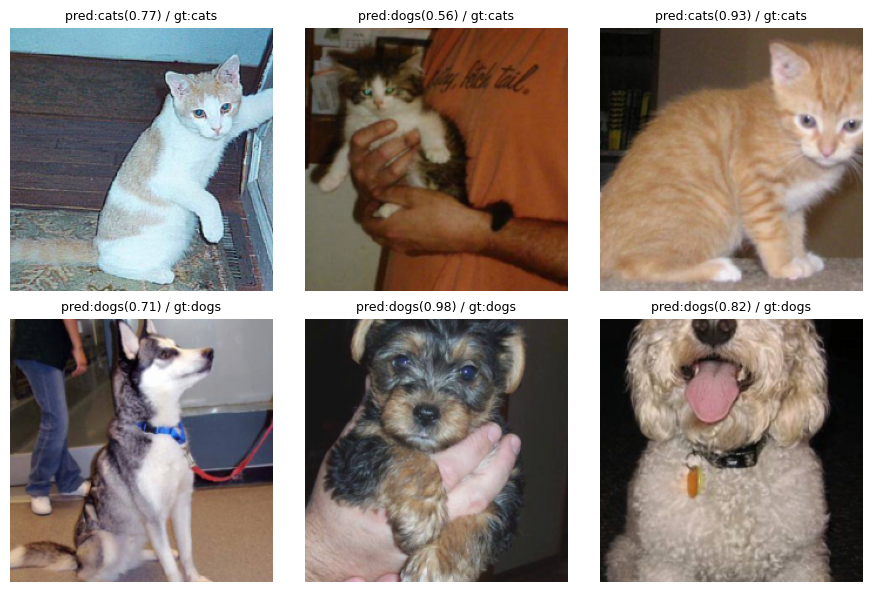

✅ Saved: /content/outputs/preds_grid_balanced.png


In [11]:
import os, numpy as np, torch, matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# 데이터 경로 & 출력 경로
data_dir = "/content/sample_computer_vision"
OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# 데이터셋 로드 (val만)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
image_datasets = {"val": datasets.ImageFolder(os.path.join(data_dir, "val"), tfm)}
class_names = image_datasets["val"].classes
dataset = image_datasets["val"]
print("✅ Loaded classes:", class_names)

# 학습 완료된 모델 로드
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model.load_state_dict(torch.load(f"{OUT_DIR}/best_model.pth", map_location=device))
model = model.to(device)
model.eval()

# 시각화
_IMAGENET_MEAN = np.array(mean)
_IMAGENET_STD  = np.array(std)
def denorm(img_tensor):
    x = img_tensor.detach().cpu().numpy().transpose(1,2,0)
    return np.clip(x * _IMAGENET_STD + _IMAGENET_MEAN, 0, 1)

per_class = 3
num_classes = len(class_names)
idxs = [[] for _ in range(num_classes)]
for i in range(len(dataset)):
    _, y = dataset[i]
    if len(idxs[y]) < per_class:
        idxs[y].append(i)
    if all(len(v) >= per_class for v in idxs):
        break

imgs, titles = [], []
with torch.inference_mode():
    for c in range(num_classes):
        for i in idxs[c]:
            x, y = dataset[i]
            out = model(x.unsqueeze(0).to(device))
            prob = torch.softmax(out, dim=1).cpu().squeeze(0)
            pred = int(prob.argmax()); conf = float(prob[pred])
            imgs.append(x)
            titles.append(f"pred:{class_names[pred]}({conf:.2f}) / gt:{class_names[y]}")

rows = 2 if len(imgs) <= 8 else 3
cols = int(np.ceil(len(imgs)/rows))
plt.figure(figsize=(cols*3, rows*3))
for i, x in enumerate(imgs, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(denorm(x)); plt.axis("off")
    plt.title(titles[i-1], fontsize=9)
plt.tight_layout()
save_path = f"{OUT_DIR}/preds_grid_balanced.png"
plt.savefig(save_path, dpi=150); plt.show()
print("✅ Saved:", save_path)
